# Basic Agent

In [55]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_key = os.getenv("GROQ_API_KEY").strip()
print(os.getenv("GROQ_API_KEY")[:10])

 gsk_rqV2s


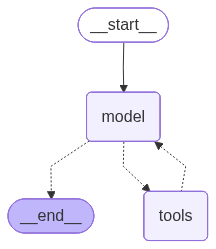

In [56]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent

def weather (city:str)->str:
    """Get the weather of city"""                  # Docstring is needed , else error will arise
    return f"The weather in {city} is sunny."

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY").strip()
)

agent = create_agent(
    model=llm,
    tools=[weather],
    system_prompt="You are a helpful assistant"
)

agent

In [57]:
response = agent.invoke({"messages":[{"role":"user" , "content":"what is the weather of new york city ?"}]})

In [59]:
response["messages"]

[HumanMessage(content='what is the weather of new york city ?', additional_kwargs={}, response_metadata={}, id='3f9bb721-ea34-451a-8ffd-b59465645796'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4v99dxmyt', 'function': {'arguments': '{"city":"new york city"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 222, 'total_tokens': 238, 'completion_time': 0.071335475, 'completion_tokens_details': None, 'prompt_time': 0.011930289, 'prompt_tokens_details': None, 'queue_time': 0.056121551, 'total_time': 0.083265764}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e824c-3b31-7601-a6ef-9cd499956653-0', tool_calls=[{'name': 'weather', 'args': {'city': 'new york city'}, 'id': '4v99dxmyt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

In [61]:
agent.invoke({"messages":"what is the weather of india"})

{'messages': [HumanMessage(content='what is the weather of india', additional_kwargs={}, response_metadata={}, id='66882cef-4d22-45a6-b94e-9e4a9cabdabd'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5e7rqwjn7', 'function': {'arguments': '{"city":"India"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 219, 'total_tokens': 233, 'completion_time': 0.065684491, 'completion_tokens_details': None, 'prompt_time': 0.02359652, 'prompt_tokens_details': None, 'queue_time': 0.180425049, 'total_time': 0.089281011}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e824f-0682-79a1-970f-de24c51d1b0d-0', tool_calls=[{'name': 'weather', 'args': {'city': 'India'}, 'id': '5e7rqwjn7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

# Models Integration with LLM